In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install SimpleITK nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 13.8 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/rouge1616/Spine-Mets-CT-SEG.git

fatal: destination path 'Spine-Mets-CT-SEG' already exists and is not an empty directory.


In [ ]:
input_folder = "/content/drive/MyDrive/TCIA_Original/spine_mets_ct_seg"

output_folder = "/content/drive/MyDrive/TCIA_Original/nifti_images/Spine-Mets-CT-SEG-NIFTI"

In [ ]:
!pip install dcmqi

In [ ]:
!which segimage2itkimage

/usr/local/bin/segimage2itkimage


In [ ]:
path_to_segimage2itkimage = "/usr/local/bin/segimage2itkimage"

In [ ]:
script_path = "/content/tcia_dcm2nifti.py"

In [ ]:
!which segimage2itkimage

/usr/local/bin/segimage2itkimage


Convert to Nifti data format using provided file

In [ ]:
!python tcia_dcm2nifti.py

Converted CT: /content/drive/MyDrive/TCIA_Original/spine_mets_ct_seg/15040/05087/34233 -> /content/drive/MyDrive/TCIA_Original/nifti_images/Spine-Mets-CT-SEG-NIFTI/15040/15040_ct.nii.gz
Running dcmqi: /usr/local/bin/segimage2itkimage --inputDICOM /content/drive/MyDrive/TCIA_Original/spine_mets_ct_seg/15040/05087/09944/c7da921a-4ff8-4bb6-856c-12440e55eb02.dcm --outputDirectory /content/drive/MyDrive/TCIA_Original/nifti_images/Spine-Mets-CT-SEG-NIFTI/15040 --mergeSegments -t nii -p 15040_seg
dcmqi repository URL: https://github.com/QIICR/dcmqi revision: 60d63dc tag: v1.5.6
Loading DICOM SEG file /content/drive/MyDrive/TCIA_Original/spine_mets_ct_seg/15040/05087/09944/c7da921a-4ff8-4bb6-856c-12440e55eb02.dcm
W: DeviceSerialNumber (0018,1000) absent in EnhancedGeneralEquipmentModule (type 1)
Row direction: 1 0 0
Col direction: 0 -1 0
Z direction: 0 0 -1
Total frames: 1531
Total frames with unique IPP: 789
Total overlapping frames: 617
Origin: [-203.091, -61.4092, -56.5]
Slice extent: 394
S

No need to run above code again

Conclusion

CT and segmentation are spatially aligned
- No registration, affine correction, flipping, or orientation fixes are required.

CT and SEG have different Z dimensions
- The segmentation only spans the annotated spinal region rather than the full CT acquisition.
- so never assume ct.shape==seg.shape

Use the segmentation itself to locate vertebrae
- Do not manually search CT slices. Instead:
- mask = (seg_data == vertebra_id)


  coords = np.where(mask)

Not every patient contains all vertebrae
- therefore use,
- present_labels = np.unique(seg_data)


  present_labels = present_labels[present_labels > 0]

Slice thickness varies substantially
- isotropic resampling to 1x1x1m is needed



# Restart checks ------------------------------

In [ ]:
from pathlib import Path

PATIENT_ID = "15067"
DATASET_ROOT = Path("/content/drive/MyDrive/TCIA_Original/nifti_images/Spine-Mets-CT-SEG-NIFTI")

patient_dir = DATASET_ROOT / PATIENT_ID

ct_path = patient_dir / "15067_ct.nii.gz"
seg_path = patient_dir / "15067_seg-1.nii.gz"

print("Patient:", PATIENT_ID)
print("CT exists :", ct_path.exists())
print("SEG exists:", seg_path.exists())

print("\nCT path:")
print(ct_path)

print("\nSEG path:")
print(seg_path)

Patient: 15067
CT exists : True
SEG exists: True

CT path:
/content/drive/MyDrive/TCIA_Original/nifti_images/Spine-Mets-CT-SEG-NIFTI/15067/15067_ct.nii.gz

SEG path:
/content/drive/MyDrive/TCIA_Original/nifti_images/Spine-Mets-CT-SEG-NIFTI/15067/15067_seg-1.nii.gz


In [ ]:
import SimpleITK as sitk

ct_img = sitk.ReadImage(str(ct_path))
seg_img = sitk.ReadImage(str(seg_path))

print("=" * 50)
print("CT IMAGE")
print("=" * 50)

print("Size      :", ct_img.GetSize())
print("Spacing   :", ct_img.GetSpacing())
print("Origin    :", ct_img.GetOrigin())
print("Direction :", ct_img.GetDirection())

print("\n")

print("=" * 50)
print("SEG IMAGE")
print("=" * 50)

print("Size      :", seg_img.GetSize())
print("Spacing   :", seg_img.GetSpacing())
print("Origin    :", seg_img.GetOrigin())
print("Direction :", seg_img.GetDirection())

CT IMAGE
Size      : (512, 512, 797)
Spacing   : (0.83984375, 0.83984375, 0.5)
Origin    : (-221.580078125, -508.580078125, -364.0)
Direction : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


SEG IMAGE
Size      : (512, 512, 771)
Spacing   : (0.8398438096046448, 0.8398438096046448, 0.5)
Origin    : (-221.58009338378906, -79.419921875, 21.0)
Direction : (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, -1.0)


In [ ]:
ct_np = sitk.GetArrayFromImage(ct_img)
seg_np = sitk.GetArrayFromImage(seg_img)

print("\nNumPy shapes")
print("CT :", ct_np.shape)
print("SEG:", seg_np.shape)


NumPy shapes
CT : (797, 512, 512)
SEG: (771, 512, 512)


In [ ]:


seg_resampled = sitk.Resample(
    seg_img,
    ct_img,
    sitk.Transform(),
    sitk.sitkNearestNeighbor,
    0,
    seg_img.GetPixelID()
)

seg_resampled_np = sitk.GetArrayFromImage(
    seg_resampled
)

print("CT shape :", ct_np.shape)
print("SEG shape:", seg_resampled_np.shape)

print("\nResampled SEG metadata")
print("Size      :", seg_resampled.GetSize())
print("Spacing   :", seg_resampled.GetSpacing())
print("Origin    :", seg_resampled.GetOrigin())
print("Direction :", seg_resampled.GetDirection())

CT shape : (797, 512, 512)
SEG shape: (797, 512, 512)

Resampled SEG metadata
Size      : (512, 512, 797)
Spacing   : (0.83984375, 0.83984375, 0.5)
Origin    : (-221.580078125, -508.580078125, -364.0)
Direction : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


In [ ]:
import numpy as np

labels = np.unique(seg_resampled_np)

print("Labels present:")
print(labels)

Labels present:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [ ]:
#extract t5 mask
T5_LABEL = 5

t5_mask = seg_resampled_np == T5_LABEL

print("T5 voxel count:", t5_mask.sum())

T5 voxel count: 77616


In [ ]:
z_indices = np.where(t5_mask)[0]

print("T5 slice range:")
print(z_indices.min(), z_indices.max())

print("Number of slices:")
print(len(np.unique(z_indices)))

T5 slice range:
546 650
Number of slices:
104


In [ ]:
import matplotlib.pyplot as plt

for z in range(
    z_indices.min(),
    z_indices.max() + 1
):
    plt.figure(figsize=(8,8))

    plt.imshow(
        ct_np[z],
        cmap="gray",
        vmin=-450,
        vmax=1050
    )

    plt.contour(
        t5_mask[z],
        colors="red",
        linewidths=2
    )

    plt.title(f"T5 Overlay - Slice {z}")
    plt.axis("off")

    plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Next Preprocessing Step

In [ ]:
#create the binary mask
T5_LABEL = 5
t5_mask = (seg_resampled_np == T5_LABEL)

In [ ]:
#find the bounding box
coords = np.where(t5_mask)

zmin, zmax = coords[0].min(), coords[0].max()
ymin, ymax = coords[1].min(), coords[1].max()
xmin, xmax = coords[2].min(), coords[2].max()

print("Bounding box:")
print("z:", zmin, zmax)
print("y:", ymin, ymax)
print("x:", xmin, xmax)

Bounding box:
z: 546 650
y: 322 418
x: 201 291


In [ ]:
margin_x = 10
margin_y = 10
margin_z = 5

xmin = max(0, xmin - margin_x)
xmax = min(ct_np.shape[2], xmax + margin_x)

ymin = max(0, ymin - margin_y)
ymax = min(ct_np.shape[1], ymax + margin_y)

zmin = max(0, zmin - margin_z)
zmax = min(ct_np.shape[0], zmax + margin_z)

In [ ]:
ct_crop = ct_np[
    zmin:zmax+1,
    ymin:ymax+1,
    xmin:xmax+1
]

mask_crop = t5_mask[
    zmin:zmax+1,
    ymin:ymax+1,
    xmin:xmax+1
]

print("CT crop shape :", ct_crop.shape)
print("Mask shape    :", mask_crop.shape)

CT crop shape : (115, 117, 111)
Mask shape    : (115, 117, 111)


In [ ]:
import matplotlib.pyplot as plt

for z in range(ct_crop.shape[0]):

    plt.figure(figsize=(8,8))

    plt.imshow(
        ct_crop[z],
        cmap="gray",
        vmin=-450,
        vmax=1050
    )

    plt.contour(
        mask_crop[z],
        colors="red",
        linewidths=2
    )

    plt.title(f"Cropped T5 Slice {z+1}/{ct_crop.shape[0]}")
    plt.axis("off")

    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
print("CT crop shape:", ct_crop.shape)

print("Original CT shape:", ct_np.shape)

print(
    f"Volume reduction: "
    f"{ct_np.size / ct_crop.size:.1f}x"
)

CT crop shape: (115, 117, 111)
Original CT shape: (797, 512, 512)
Volume reduction: 139.9x


In [ ]:
mask_fraction = mask_crop.sum() / mask_crop.size

print(
    f"Mask occupancy: "
    f"{100*mask_fraction:.2f}%"
)

Mask occupancy: 5.20%


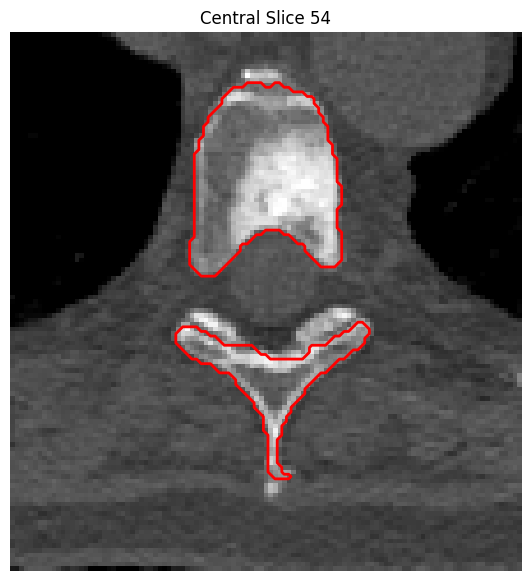

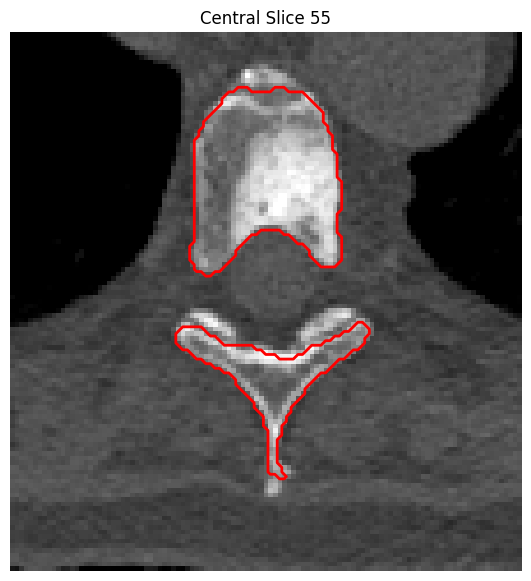

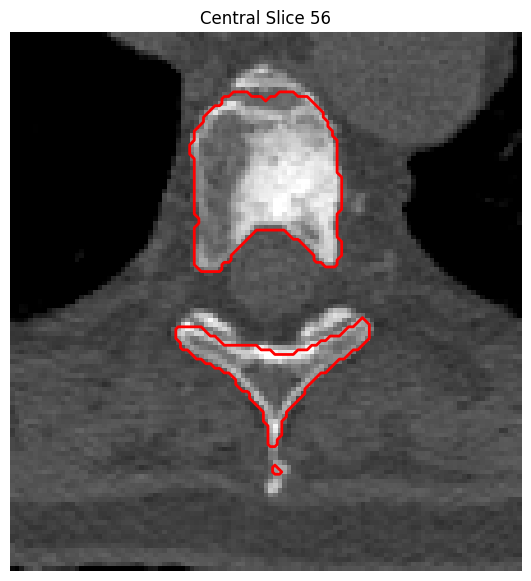

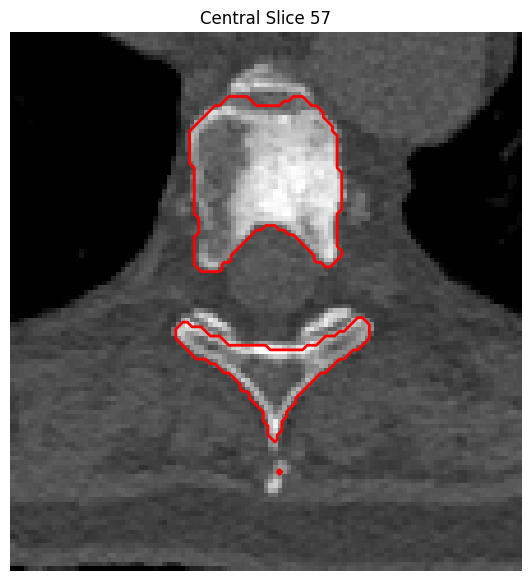

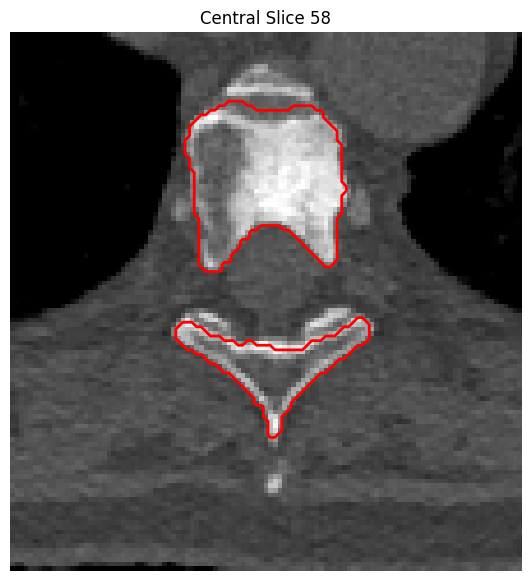

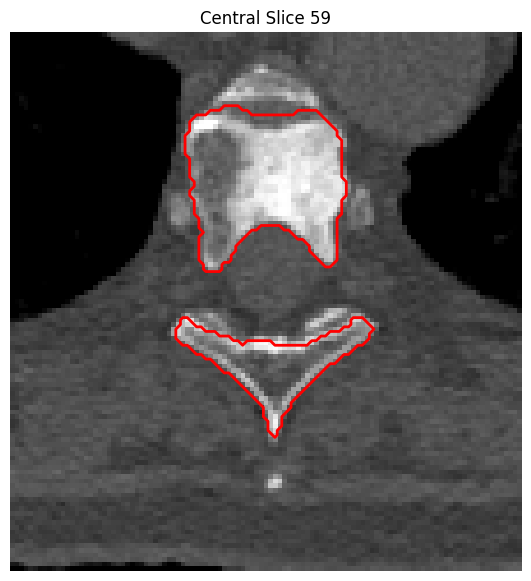

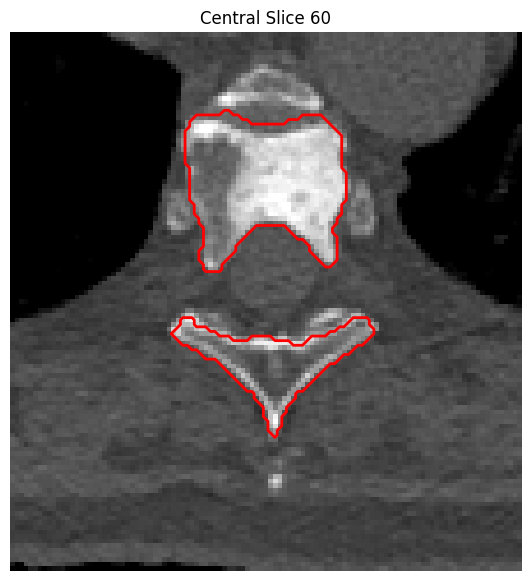

In [ ]:
middle = ct_crop.shape[0] // 2

for z in range(
    max(0, middle-3),
    min(ct_crop.shape[0], middle+4)
):

    plt.figure(figsize=(7,7))

    plt.imshow(
        ct_crop[z],
        cmap="gray",
        vmin=-450,
        vmax=1050
    )

    plt.contour(
        mask_crop[z],
        colors="red",
        linewidths=2
    )

    plt.title(f"Central Slice {z}")
    plt.axis("off")

    plt.show()

Ready for next steps

✓ CT and SEG load correctly
✓ SEG resampling onto CT geometry works
✓ T5 label exists
✓ Consecutive overlays are anatomically correct
✓ Bounding box extraction works
✓ Crop contains complete vertebra
✓ Context around vertebra preserved

In [ ]:
ct_crop.shape
# (115,117,111)

(115, 117, 111)

In [ ]:
ct_crop_img = sitk.GetImageFromArray(ct_crop)

ct_crop_img.SetSpacing(ct_img.GetSpacing())
ct_crop_img.SetDirection(ct_img.GetDirection())
ct_crop_img.SetOrigin((0,0,0))

In [ ]:
ct_crop_img

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x7e7b8c292230> >

In [ ]:
old_spacing = ct_crop_img.GetSpacing()
old_size = ct_crop_img.GetSize()

print("Old spacing:", old_spacing)
print("this means dimensions of a single vozel")
print("Old size:", old_size)

Old spacing: (0.83984375, 0.83984375, 0.5)
this means dimensions of a single vozel
Old size: (111, 117, 115)


In [ ]:
new_spacing = (1.0, 1.0, 1.0)

new_size = [
    int(round(old_size[i] * old_spacing[i] / new_spacing[i]))
    for i in range(3)
]

print("New size:", new_size)

New size: [93, 98, 58]


In [ ]:
#means every two original slices become one.

In [ ]:
#resample now

In [ ]:
resampler = sitk.ResampleImageFilter()

resampler.SetOutputSpacing(new_spacing)
resampler.SetSize(new_size)

resampler.SetOutputDirection(
    ct_crop_img.GetDirection()
)

resampler.SetOutputOrigin(
    ct_crop_img.GetOrigin()
)

resampler.SetInterpolator(
    sitk.sitkLinear
)

ct_iso_img = resampler.Execute(
    ct_crop_img
)

In [ ]:
ct_iso = sitk.GetArrayFromImage(
    ct_iso_img
)

print(ct_iso.shape)

(58, 98, 93)


In [ ]:
#verify physical dimensions preserved

#Befpre
physical_before = np.array(
    ct_crop_img.GetSize()
) * np.array(
    ct_crop_img.GetSpacing()
)

print(physical_before)

[93.22265625 98.26171875 57.5       ]


In [ ]:

#after

physical_after = np.array(
    ct_iso_img.GetSize()
) * np.array(
    ct_iso_img.GetSpacing()
)

print(physical_after)

[93. 98. 58.]


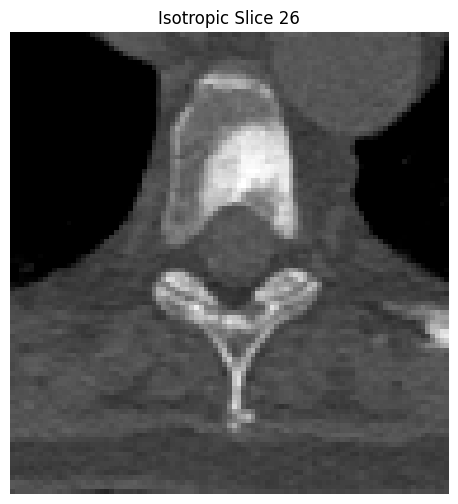

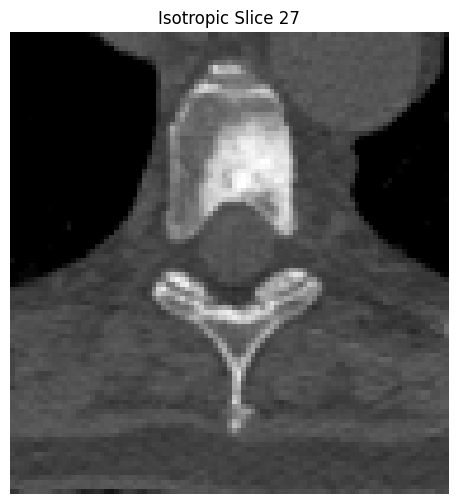

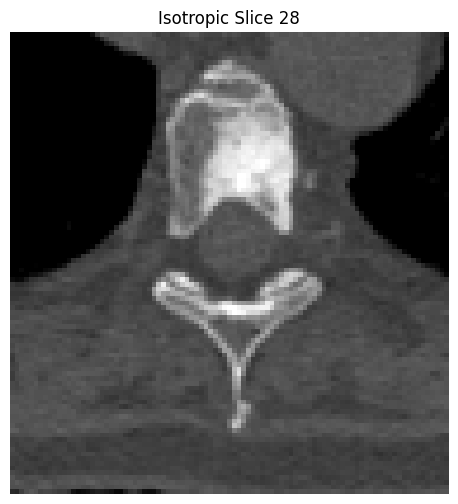

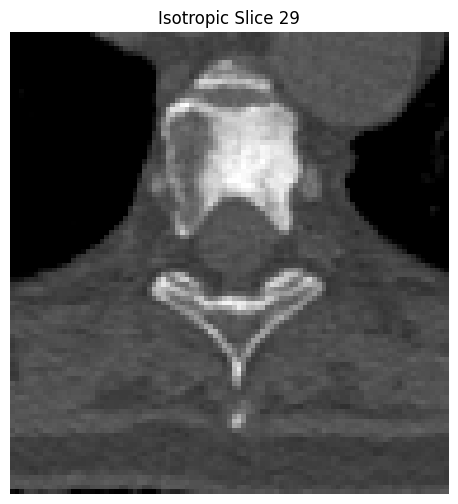

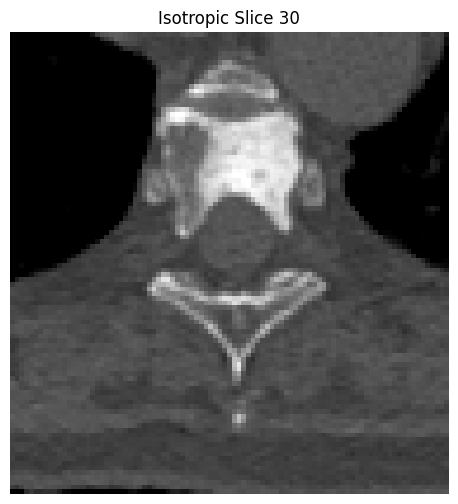

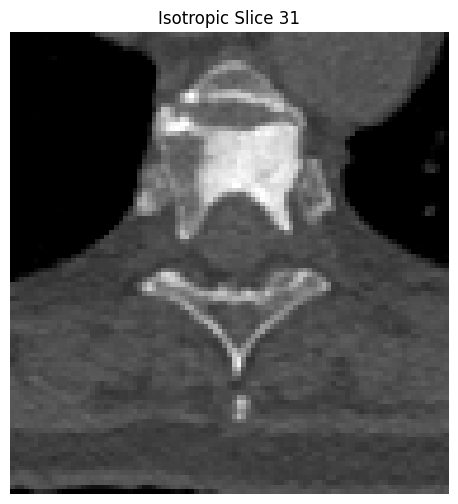

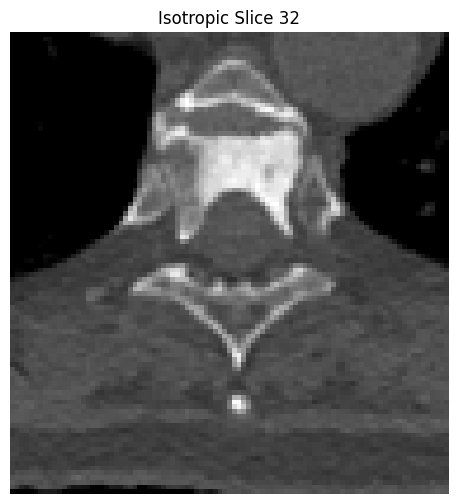

In [ ]:
mid = ct_iso.shape[0] // 2

for z in range(mid-3, mid+4):

    plt.figure(figsize=(6,6))

    plt.imshow(
        ct_iso[z],
        cmap="gray",
        vmin=-450,
        vmax=1050
    )

    plt.title(
        f"Isotropic Slice {z}"
    )

    plt.axis("off")

    plt.show()

In [ ]:
#aplying bone window

HU_MIN = -450
HU_MAX = 1050

ct_windowed = np.clip(
    ct_iso,
    HU_MIN,
    HU_MAX
)

print(
    ct_windowed.min(),
    ct_windowed.max()
)

#best HU range for bone


-450 1050


In [ ]:
#normalize intensitites
ct_normalized = (
    (ct_windowed - HU_MIN)
    / (HU_MAX - HU_MIN)
)

ct_normalized = (
    ct_normalized * 2
) - 1

print(
    ct_normalized.min(),
    ct_normalized.max()
)

-1.0 1.0


In [ ]:
#resize to network inout size
img = sitk.GetImageFromArray(
    ct_normalized.astype(np.float32)
)

img.SetSpacing(
    ct_iso_img.GetSpacing()
)

In [ ]:
target_size = (64,64,64)

resampler = sitk.ResampleImageFilter()

resampler.SetSize(target_size)

resampler.SetOutputSpacing(
    [
        img.GetSize()[i]
        * img.GetSpacing()[i]
        / target_size[i]
        for i in range(3)
    ]
)

resampler.SetInterpolator(
    sitk.sitkLinear
)

img_64 = resampler.Execute(img)

ct_final = sitk.GetArrayFromImage(
    img_64
)

print(ct_final.shape)

(64, 64, 64)


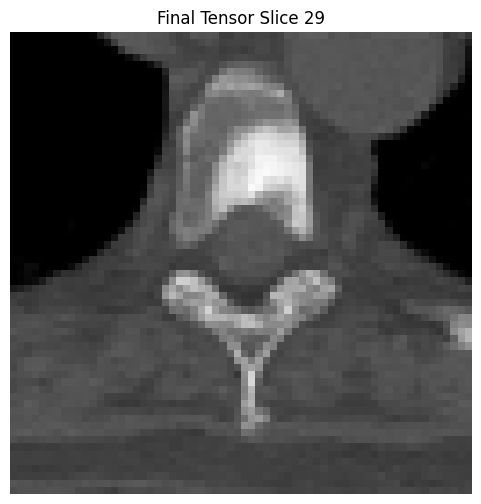

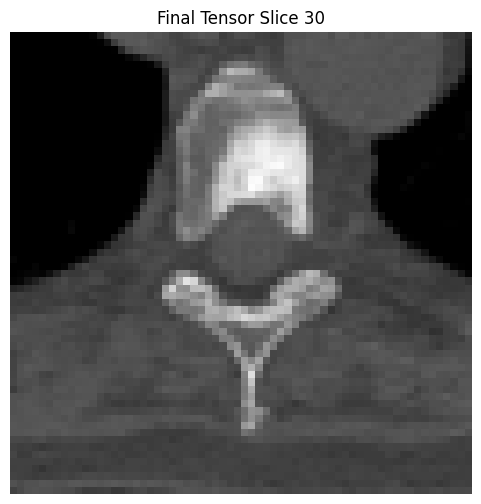

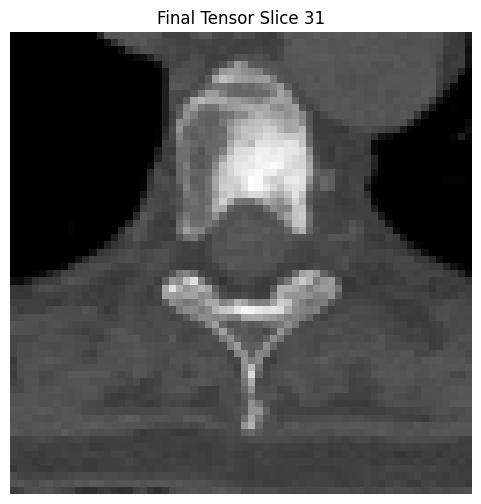

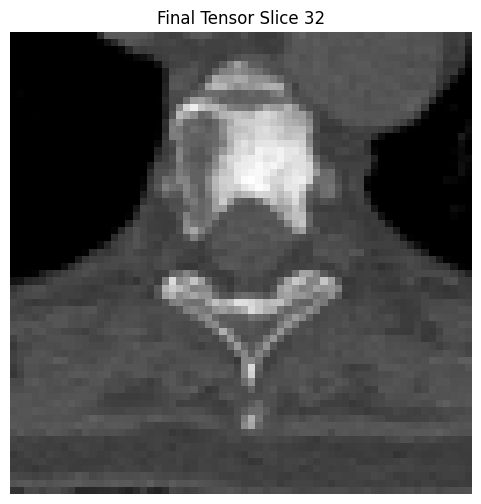

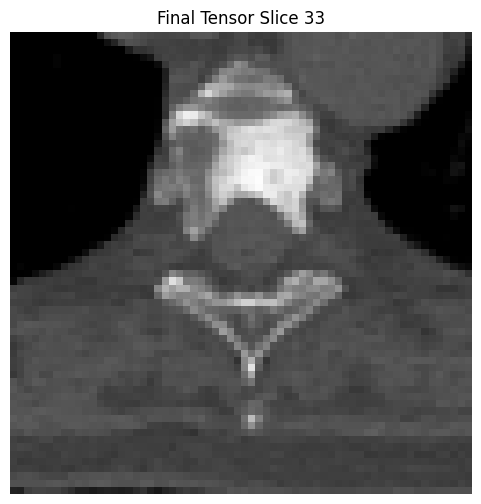

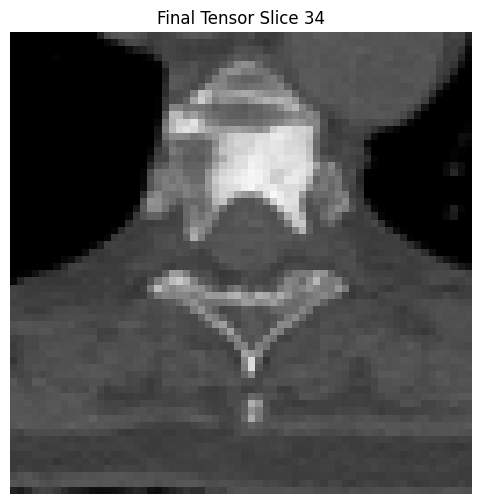

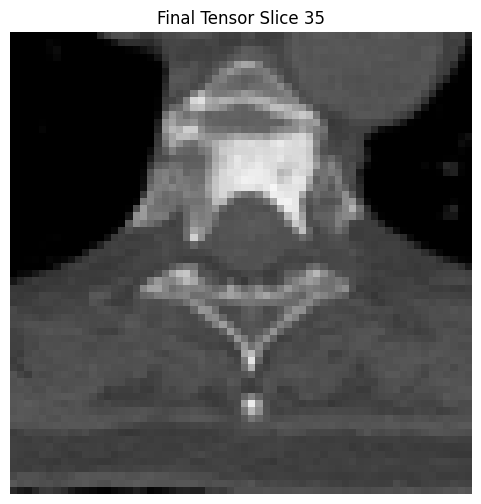

In [ ]:
middle = ct_final.shape[0] // 2

for z in range(middle-3, middle+4):

    plt.figure(figsize=(6,6))

    plt.imshow(
        ct_final[z],
        cmap="gray",
        vmin=-1,
        vmax=1
    )

    plt.title(
        f"Final Tensor Slice {z}"
    )

    plt.axis("off")

    plt.show()